## B1. LOAD thư viện cần dùng và viết các hàm tính sẵn (GINI, PSI, WOE and IV..)

In [15]:
# LOAD LIBRARIES
import os
import logging
from pathlib import Path
import pandas as pd
import numpy as np
import json
import shap
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from datetime import datetime
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score,classification_report, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s - %(message)s",
)

logger = logging.getLogger("credit_score_model_training")

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "facts_dataset.csv"
ARTIFACT_DIR = PROJECT_ROOT / "scripts" / "credit_score_model" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "credit_score_model.joblib"

logger.info(f"Data path: {DATA_PATH}")
logger.info(f"Artifact dir: {ARTIFACT_DIR}")

2025-11-19 12:40:14,575 INFO credit_score_model_training - Data path: ../data/facts_dataset.csv
2025-11-19 12:40:14,576 INFO credit_score_model_training - Artifact dir: ../scripts/credit_score_model/artifacts


In [16]:
# CODING SOME PRE-DEFINED FUNCTIONS
def gini_from_auc(y_true, y_score):
    """Calculate Gini coefficient from ROC AUC."""
    _auc = roc_auc_score(y_true, y_score)
    return 2 * _auc - 1

def _psi_from_props(train_percentage, test_percentage, eps=1e-6):
    # Compare input percentages to calculate PSI, replace zeros to avoid division by zero / log(0)
    _predicted = np.clip(train_percentage, eps, 1.0)
    _actual = np.clip(test_percentage, eps, 1.0)
    return np.sum((_predicted - _actual) * np.log(_predicted / _actual))

def compute_psi_series(_expected, _actual, bins=10):
    """
    Compute PSI for one feature (expected = reference/train, actual = new/test).
    Handles numeric (quantile bins) and categorical features.
    """
    _expected = pd.Series(_expected).dropna()
    _actual = pd.Series(_actual).dropna()
    if _expected.empty or _actual.empty: return np.nan

    _unique_vals = np.union1d(_expected.unique(), _actual.unique())
    _is_categorical = len(_unique_vals) <= bins

    try:
        # By default, use raw series for binning (categorical)
        _exp_binned, _act_binned = _expected, _actual
        _levels = list(_unique_vals)

        if not _is_categorical:
            # Numeric: try to create quantile bins
            _quantiles = np.linspace(0, 1, bins + 1)
            breaks = np.unique(np.quantile(_expected, _quantiles))
            
            if len(breaks) > 1:
                # If successful, use binned series and new levels
                _exp_binned = pd.cut(_expected, bins=breaks, include_lowest=True, duplicates='drop')
                _act_binned = pd.cut(_actual, bins=breaks, include_lowest=True, duplicates='drop')
                _levels = _exp_binned.cat.categories
            # If len(breaks) <= 1, it fails and automatically uses the categorical logic defined above
 
        _exp_counts = _exp_binned.value_counts(normalize=True).reindex(_levels, fill_value=0).values
        _act_counts = _act_binned.value_counts(normalize=True).reindex(_levels, fill_value=0).values
        
        return _psi_from_props(_exp_counts, _act_counts)

    except Exception:
        return np.nan

def calculate_psi_dataframe(train_df, test_df, bins=10, sort=True):
    """
    Calculate PSI for all columns present in both train_df and test_df.
    Returns a DataFrame with 'feature' and 'psi' columns.
    """
    _common_cols = [c for c in train_df.columns if c in test_df.columns]
    _results = []
    for col in _common_cols:
        _psi_val = compute_psi_series(train_df[col], test_df[col], bins=bins)
        _results.append((col, _psi_val))
    _psi_df = pd.DataFrame(_results, columns=['feature', 'psi'])
    if sort:
        _psi_df = _psi_df.sort_values('psi', ascending=False).reset_index(drop=True)
    return _psi_df

def calculate_woe_iv(data, target_col, max_categories=20, n_bins=10):
    """
    Calculates Weight of Evidence (WoE) and Information Value (IV) for all features in a DataFrame
    against a specified binary target column.

    Assumes:
    - Target column is binary (0 = 'Good', 1 = 'Bad').
    - 'Good' is the non-event (e.g., loan paid).
    - 'Bad' is the event (e.g., loan default, FPD10+).

    Args:
        data (pd.DataFrame): The input DataFrame with features and target.
        target_col (str): The name of the binary target column.
        max_categories (int): Threshold for treating a numeric feature as categorical.
                               If nunique() <= max_categories, it's treated as categorical.
        n_bins (int): Number of bins to create for continuous features (using quantiles).

    Returns:
        tuple:
            - iv_summary_df (pd.DataFrame): DataFrame with 'Variable' and 'IV' columns,
                                            sorted by IV descending.
            - woe_tables (dict): A dictionary where keys are variable names and
                                 values are DataFrames containing the detailed WoE
                                 calculations for that variable.
    """
    
    # Separate features from target
    _features = [col for col in data.columns if col != target_col]
    # Calculate total goods and bads
    _total_bads = data[target_col].sum()
    _total_goods = len(data) - _total_bads
    # Add a small epsilon to prevent division by zero (ln(0))
    _eps = 0.5
    
    _iv_list = []
    _woe_tables = {}

    print(f"Total Goods (Target=0): {_total_goods}")
    print(f"Total Bads (Target=1): {_total_bads}")
    print("-" * 30)

    for feature in _features:
        try:
            # --- 1. Binning & Grouping ---
            # Create a clean version of the feature, filling NaNs
            _feature_data = data[feature].fillna('Missing')
            # Determine if continuous or categorical
            if pd.api.types.is_numeric_dtype(data[feature]) and data[feature].nunique() > max_categories:
                # --- Continuous Feature ---
                # Bin using quantiles. We use data[feature] (not feature_data) (avoid trying to bin the 'Missing' string)
                _binned_feature = pd.qcut(data[feature], q=n_bins, duplicates='drop').astype(str)
                # Combine binned data with the 'Missing' values (.cat.add_categories is for pd.Categorical, but .astype(str) handles it)
                _binned_feature = _binned_feature.fillna('Missing')
                
            else:
                # --- Categorical Feature ---
                # convert to string to ensure consistency
                _binned_feature = _feature_data.astype(str)          
            # Name the binned series for the crosstab
            _binned_feature.name = 'Category'
            # --- 2. crosstab Calculation ---
            # Create the contingency table
            _crosstab = pd.crosstab(_binned_feature, data[target_col])
            # Ensure both 'Good' (0) and 'Bad' (1) columns exist
            if 0 not in _crosstab.columns:   _crosstab[0] = 0
            if 1 not in _crosstab.columns:   _crosstab[1] = 0       
            # Rename columns
            _crosstab = _crosstab.rename(columns={0: 'Goods', 1: 'Bads'})
            # Add epsilon smoothing
            _crosstab['Goods'] = _crosstab['Goods'] + _eps
            _crosstab['Bads'] = _crosstab['Bads'] + _eps

            # --- 3. WoE and IV Calculation ---
            # Calculate percentages
            _crosstab['%_Goods'] = _crosstab['Goods'] / (_total_goods + _eps)
            _crosstab['%_Bads'] = _crosstab['Bads'] / (_total_bads + _eps)            
            # Calculate WoE
            _crosstab['WoE'] = np.log(_crosstab['%_Goods'] / _crosstab['%_Bads'])
            # Calculate IV for each bin
            _crosstab['IV_Bin'] = (_crosstab['%_Goods'] - _crosstab['%_Bads']) * _crosstab['WoE']
            # Calculate totals for the category
            _crosstab['Total_Bin'] = _crosstab['Goods'] + _crosstab['Bads']
            _crosstab['%_Population'] = _crosstab['Total_Bin'] / (_total_goods + _total_bads)

            # --- 4. Store Results ---
            # Sum IV for the entire variable
            total_iv = _crosstab['IV_Bin'].sum()
            # Get WoE values as a dictionary (bin: woe)
            woe_dict = _crosstab['WoE'].to_dict()
            # Append to the summary list
            _iv_list.append({'Variable': feature, 'IV': total_iv, 'WoE_Values': woe_dict})
            # Store the detailed WoE table
            _woe_tables[feature] = _crosstab.reset_index()
            #print(f"Successfully processed: {feature}")

        except Exception as e:
            print(f"--- FAILED to process {feature}: {e} ---")

    # --- 5. Final Output ---
    _iv_summary_df = pd.DataFrame(_iv_list).sort_values(by='IV', ascending=False).reset_index(drop=True)
    return _iv_summary_df, _woe_tables

def get_feature_selection(data, target_col,is_l1=True):
    
    # Separate features and target
    _X = data.drop(columns=target_col)
    _y = data[target_col]
    
    _random_state = 42
    _split_ratio = 0.3

    # --- 1. Define Feature Types ---
    # Robustly identify numeric and categorical features. Use pandas type checks
    # so that non-numeric columns (including strings / categories) are not treated
    # as numeric
    _numerical_cols = [col for col in _X.columns if pd.api.types.is_numeric_dtype(_X[col])]
    _categorical_cols = [col for col in _X.columns if col not in _numerical_cols]
    print(f"Categorical features: {_categorical_cols}")
    print(f"Numerical features: {_numerical_cols}")

    # --- 2. Create Preprocessing Pipelines ---
    # Pipeline for numerical features:
    if is_l1:
        # feature engineering for l1
        _numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())    ])
        # classifier = LogisticRegression()
        _model_kernel = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=0.1,  # Inverse of regularization strength
            random_state=_random_state  )
    else:
        # feature engineering for rf
        _numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))    ])
        # classifier = RandomForestClassifier()
        _model_kernel = RandomForestClassifier(
            n_estimators=100,   # Number of trees
            random_state=_random_state, 
            n_jobs=-1      )    # Use all available cores

    # Pipeline for categorical features:
    # 1. Impute missing values with a constant string 'Missing'.
    # 2. One-hot encode the categories.
    _categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))  ])

    # --- 3. Combine Pipelines with ColumnTransformer ---
    # This transformer applies the correct pipeline to the correct columns
    _preprocessor = ColumnTransformer(
        transformers=[
            ('num', _numerical_transformer, _numerical_cols),
            ('cat', _categorical_transformer, _categorical_cols)],
        remainder='passthrough' ) # In case any columns are left out    

    # --- 4. Create the Full Model Pipeline ---
    # This will force more coefficients to zero, performing more selection.  
    model = Pipeline(steps=[
        ('preprocessor', _preprocessor),
        ('classifier', _model_kernel)   ])

    # --- 5. Train the Model ---
    X_train, X_test, y_train, y_test = train_test_split(_X, _y, test_size=_split_ratio, random_state=_random_state)
    model.fit(X_train, y_train)
    print(f"Model accuracy on test set: {model.score(X_test, y_test):.4f}")

    
    _classifier = model.named_steps['classifier']            # Get the trained classifier step
    _preprocessor_step = model.named_steps['preprocessor']   # Get the preprocessor step
    # Get the feature names after one-hot encoding
    # This is the trickiest part
    try:
        _onehotencode_categories = _preprocessor_step.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(_categorical_cols)
    except AttributeError:
        # Fallback for older scikit-learn versions
        _onehotencode_categories = _preprocessor_step.named_transformers_['cat'].named_steps['onehot'].get_feature_names(_categorical_cols)

    # Combine numerical and one-hot-encoded categorical names
    _all_feature_names = _numerical_cols + list(_onehotencode_categories)
    
    if is_l1: _feature_coeff = _classifier.coef_[0]
    else: _feature_coeff = _classifier.feature_importances_
    # Create a DataFrame of features and their L1 coefficients
    _coefficients = pd.DataFrame({
        'Feature': _all_feature_names,
        'Coefficient': _feature_coeff  # Get the first (and only) set of coeffs
    })
    
    # Sort by absolute value of coefficient to see importance
    _coefficients['Abs_Coefficient'] = _coefficients['Coefficient'].abs()
    _coefficients = _coefficients.sort_values(by='Abs_Coefficient', ascending=False)

    return _coefficients

# Helper function to safely get nested values
def safe_get(data_dict, keys, default=None):
    """
    Safely traverses a nested dictionary.
    Example: safe_get(data, ['QHTDHT', 'QHTD', 'DONG'])
    """
    _temp = data_dict
    for key in keys:
        if isinstance(_temp, dict):
            _temp = _temp.get(key, default)
        else:
            return default
    return _temp

def extract_cic_features(raw_json_string):
    """
    Takes one raw JSON string from the CIC_DATA column,
    cleans it, parses it, and extracts a flat dictionary of features.
    """
    
    # --- 1. Initialize all features with default values ---
    _features = {
        'cic_score': None,
        'cic_rank_percentile': None,
        'cic_rank_grade': None,
        'has_bad_debt_36m': None,
        'has_group2_debt_12m': None,
        'worst_current_debt_group': None,
        'has_collateral': None
    }

    # --- 2. Clean and Parse ---
    try:
        data = json.loads(raw_json_string)
        # Get the main cic_content blob
        _cic_content = safe_get(data, ['NOIDUNG'], {})
        if not _cic_content: return _features # Return defaults if no cic_content
    # If JSON is invalid, return the default feature set
    except Exception as e:
        return _features      

    # --- 3. Extract Features (Tier 1) ---
    # convert "" or "N/A" to Nan
    _credit_score = safe_get(_cic_content, ['DIEMTD'], {})
    _features['cic_score'] = pd.to_numeric(safe_get(_credit_score, ['DIEM']), errors='coerce')
    _features['cic_rank_percentile'] = pd.to_numeric(safe_get(_credit_score, ['XEPHANGKH']), errors='coerce')
    _features['cic_rank_grade'] = pd.to_numeric(safe_get(_credit_score, ['HANG']), errors='coerce')

    _credit_history = safe_get(_cic_content, ['LSQHTD'], {})
    _baddebt_36m = safe_get(_credit_history, ['NOXAU_36THANG', 'DONG'], [])
    _features['has_bad_debt_36m'] = 1 if isinstance(_baddebt_36m, list) and len(_baddebt_36m) > 0 else 0
    
    _group2_12m = safe_get(_credit_history, ['NHOM2_12THANG']) # This might be None
    _features['has_group2_debt_12m'] = 0 if _group2_12m is None else 1 # Or more complex logic if it's a list

    # Get the list of currently active loans
    _active_loans = safe_get(_cic_content, ['QHTDHT', 'QHTD', 'DONG'], [])
    if isinstance(_active_loans, list) and len(_active_loans) > 0:
        # OBJECTIVE: find the WORST (highest number) debt group among all active loans. (Group 5 > Group 1)
        _worst_group = 0
        for loan in _active_loans:
            # Check inside CTLOAIVAY for debt groups
            _debt_detail = safe_get(loan, ['CTLOAIVAY', 'DONG'], [])
            if isinstance(_debt_detail, list) and len(_debt_detail) > 0:
                _group_str = safe_get(_debt_detail[0], ['NHOMNO']) # Get first group
                _group_num = pd.to_numeric(_group_str, errors='coerce')
                if pd.notna(_group_num) and _group_num > _worst_group:
                    _worst_group = int(_group_num)
        
        if _worst_group > 0:
            _features['worst_current_debt_group'] = _worst_group

    # --- 5. Extract Features (Tier 3) ---
    _collateral_assets_desc = safe_get(_cic_content, ['TSDB', 'MOTA_TSDB'])
    if _collateral_assets_desc:
        _features['has_collateral'] = 1 if _collateral_assets_desc != 'Không có' else 0

    return _features

def scores_and_risks_calculator(df, proba, prefix='score', PDO=20, target_score=600, target_odds=50, eps=1e-6):
    # check length
    if len(proba) != len(df):
        raise ValueError(f"Length mismatch: proba length {len(proba)} != df length {len(df)}")
    # scoring parameters
    factor = PDO / np.log(2)
    offset = target_score - (factor * np.log(target_odds))
    p = np.clip(proba, eps, 1 - eps)
    odds = (1 - p) / p
    scores = (offset + factor * np.log(odds)).astype(int)
    score_col = f'{prefix}_score'
    risk_col = f'{prefix}_risk_group'
    df[score_col] = scores
    df[risk_col] = pd.qcut(
        df[score_col],
        q=5,
        labels=['Very High Risk','High Risk','Medium Risk','Low Risk','Very Low Risk'],
        duplicates='drop'
    )
    return df


## B2. Load dữ liệu vào notebook

In [17]:
# 2.1 CHECK SOME DATA   
df = pd.read_csv(DATA_PATH, encoding='utf-8')
logger.info(f"Loaded {len(df)} rows and {len(df.columns)} columns")
df.head()

2025-11-19 12:40:15,012 INFO credit_score_model_training - Loaded 14000 rows and 77 columns


,customer_id,disbursement_date,Age,gender,occupation,month_incom,address_apply,operating_system,phone_provider,FPD10+,...,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_6M,ENQ_9M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_6M,NUM_NEW_LOAN_9M,NUM_NEW_LOAN_12M
0,AAA123,4/8/2024,21,MALE,WORKER,9000000.0,"338 Đ. Quảng Hàm, Phường 5, Gò Vấp, Thành phố ...",0,viettel,0,...,22,21,2,2,3,3,0,0,1,1
1,AAA124,4/11/2024,38,MALE,OTHER,15000000.0,"8G4R+74 Lục Nam District, Bac Giang, Vietnam",IOS,viettel,0,...,0,-1,1,1,2,2,2,3,4,4
2,AAA125,4/8/2024,36,FEMALE,EMPLOYEE,40000000.0,"Đ. Gò Xoài/24 Hẻm 181, Khu phố 18, Bình Tân, T...",IOS,mobifone,0,...,60,52,4,8,12,16,0,2,3,3
3,AAA126,4/8/2024,21,MALE,STUDENT,8000000.0,"124/8A Đ. Mạc Thiên Tích, Xuân Khánh, Ninh Kiề...",IOS,viettel,0,...,10,0,2,2,2,2,2,2,2,2
4,AAA127,4/8/2024,21,MALE,OTHER,7000000.0,"36 Phố Cao Thắng, P. Cẩm Thượng, Thành phố Hải...",0,viettel,0,...,0,-1,1,1,1,1,0,2,2,2


* Cột Age tồn tại điểm Kì dị: có 167 khách hàng riêng biệt có số tuổi chính xác bằng 124 (không tồn tại khách hàng có số tuổi > 100). Với ngành nghề và income đa dạng. Số **124** chỉ có 2 combination theo thứ tự là 12,24. 12 thấp hơn số tuổi tối thiểu có thể cho vay. Vì thế lỗi này có tỉ lệ cao là misstyping với số tuổi của khách hàng là 24. 

In [18]:
# replace 'Nam' with 'MALE' in the main dataframe
df['gender'] = df['gender'].replace('Nam', 'MALE')
df['Age'] = df['Age'].replace(124, 24)
df['disbursement_date'] = pd.to_datetime(df['disbursement_date'])

### B4.2 Extract dữ liệu từ CIC_data và áp dụng phương pháp lựa chọn feature

* Sử dụng L1 regularization để train model Logistic regression và sau đó extract coef_ từ model. Từ đó xác định feature nào nên được lựa chọn ảnh hưởng tốt nhất đến model (introduce new information, not noice). Một model Random Forest cũng được sử dụng và extract Feature_importance_ để xác định mức độ ảnh hưởng của các feature đến target.

* Dựa trên nghiên cứu từ một vài sample một số dữ liệu sau đây nên được lựa chọn làm feature để train model:
1. **Điểm tín dụng** (DIEMTD): Đây là đặc điểm tốt nhất. Điểm CIC được thiết kế để dự đoán khả năng vỡ nợ. (DIEM, XEPHANGKH, HANG)
2. **Lịch sử nợ quá hạn** (LSQHTD): Vỡ nợ trong quá khứ là yếu tố dự đoán tốt nhất về khả năng vỡ nợ trong tương lai. (NOXAU_36THANG, NHOM2_12THANG)
3. **Nhóm nợ xấu**
4. **Tài sản thế chấp** (TSDB)

In [19]:
# EXTRACTING IMPORTANT FEATURES FROM CIC_DATA JOIN TO THE MAIN DATASET
feature_series = df['CIC_DATA'].apply(extract_cic_features)
# The keys from the dictionary become the new columns
features_df = pd.json_normalize(feature_series)
# 3. Join the new features back to your original DataFrame
df_final = pd.concat([df, features_df], axis=1)

* Nếu Xây dựng model hìn dựa trên thuật toán LogisticRegression vậy Feature cốt lõi được sử dụng cho cả 3 mô hình sẽ là:

1. **Demographic**: Age, occupation, gender, operating_system, phone_provider
2. **Inquiry**: ENQ_3M, ENQ_9M
3. **Credit Card**: NUM_CC_BANK, NUM_CC_NON_BANK
4. **Loan**: MID_TERM_COUNT_NON_BANK, LONG_TERM_AMOUNT
5. **Outstanding balance**: OUTS_BAL_LOAN_M1
6. **Relationship**: NUM_NEW_LOAN_3M, NUM_NEW_LOAN_6M, NUM_NEW_LOAN_12M
7. **debt**: has_group2_debt_12m



In [20]:
#Create Preprocessing Pipelines
logger.info("Preparing features and target...")
feature_cols = ['Age', 'occupation', 'gender', 'operating_system', 'phone_provider','ENQ_3M', 'has_group2_debt_12m', 'NUM_CC_NON_BANK', 'NUM_NEW_LOAN_12M', 'MID_TERM_COUNT_NON_BANK', 'NUM_NEW_LOAN_6M', 'OUTS_BAL_LOAN_M1', 'LONG_TERM_AMOUNT', 'ENQ_9M', 'NUM_CC_BANK', 'NUM_NEW_LOAN_3M']
TARGET = 'FPD10+'
NUM_FEATURES = [col for col in feature_cols if col in df_final.select_dtypes(include=[np.number]).columns]
CAT_FEATURES = [col for col in feature_cols if col not in NUM_FEATURES]

X = df_final[NUM_FEATURES + CAT_FEATURES]
y = df_final[TARGET]


logger.info("Splitting train/test...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logger.info("Building pipeline...")
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
   # ('smote', SMOTE(sampling_strategy=1,random_state=42)),
    ('logreg', LogisticRegression( 
        penalty='l2', 
        class_weight='balanced',
        solver='liblinear', random_state=42 ))
])
logger.info("pipeline built successfully.")

logger.info("Training model...")
pipeline.fit(X_train, y_train)

logger.info("Evaluating model...")
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)
y_pred = pipeline.predict(X_test)
_precision = precision_score(y_test, y_pred)
_recall = recall_score(y_test, y_pred)
_f1 = f1_score(y_test, y_pred)
y_proba = pipeline.predict_proba(X_test)[:, 1]
auc_pr = average_precision_score(y_test, y_proba)
logger.info(f"Train Score: {train_score:.4f} | Test Score: {test_score:.4f} | Precision: {_precision:.4f} | Recall: {_recall:.4f} | F1: {_f1:.4f} | AUC-PR: {auc_pr:.4f}")

2025-11-19 12:40:15,803 INFO credit_score_model_training - Preparing features and target...
2025-11-19 12:40:15,831 INFO credit_score_model_training - Splitting train/test...
2025-11-19 12:40:15,833 INFO credit_score_model_training - Building pipeline...
2025-11-19 12:40:15,834 INFO credit_score_model_training - pipeline built successfully.
2025-11-19 12:40:15,835 INFO credit_score_model_training - Training model...
2025-11-19 12:40:15,880 INFO credit_score_model_training - Evaluating model...
2025-11-19 12:40:15,901 INFO credit_score_model_training - Train Score: 0.8669 | Test Score: 0.8789 | Precision: 0.4019 | Recall: 0.6537 | F1: 0.4978 | AUC-PR: 0.4630


In [46]:
X_train.head()

,Age,ENQ_3M,has_group2_debt_12m,NUM_CC_NON_BANK,NUM_NEW_LOAN_12M,MID_TERM_COUNT_NON_BANK,NUM_NEW_LOAN_6M,OUTS_BAL_LOAN_M1,LONG_TERM_AMOUNT,ENQ_9M,NUM_CC_BANK,NUM_NEW_LOAN_3M,occupation,gender,operating_system,phone_provider
11756,21,1,0,0,2,0,0,2,0,1,1,0,FREELANCER,MALE,IOS,mobifone
3710,20,2,0,0,3,0,2,87,0,2,0,1,WORKER,MALE,IOS,viettel
3571,23,3,0,1,2,0,2,23,0,3,1,1,WORKER,MALE,IOS,vinaphone
6926,24,1,0,0,4,0,3,28,0,3,2,3,FREELANCER,FEMALE,IOS,viettel
6224,28,1,0,1,3,0,3,1508,1488,4,0,1,OTHER,MALE,IOS,vinaphone


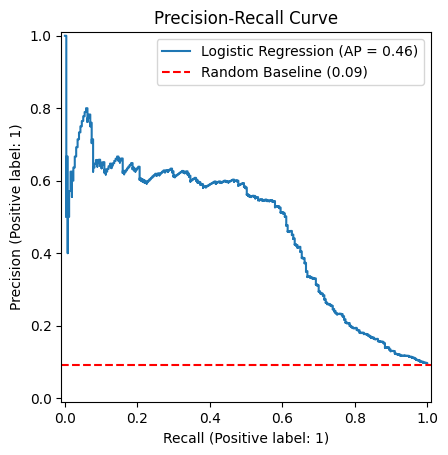

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# 1. Create the display from your predictions
# Note: Ensure y_pred_proba contains probabilities (0.0 to 1.0), not labels!
display = PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_proba, 
    name="Logistic Regression"
)

# 2. Add the "Random Baseline" for context
# We use 0.091 because that is your specific positive rate
plt.axhline(y=0.091, color='red', linestyle='--', label='Random Baseline (0.09)')

# 3. Format and Show
plt.title("Precision-Recall Curve")
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score 
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs',
        random_state=42,
        max_iter=1000
    ))
])


])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(logistic_pipeline, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
print (f"Cross-validated AUC-PR scores: {score}")
print (f"Mean AUC-PR: {score.mean():.4f} +/- {score.std():.4f}")
score = cross_val_score(sgd_pipeline, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
print (f"Cross-validated AUC-PR scores: {score}")
print (f"Mean AUC-PR: {score.mean():.4f} +/- {score.std():.4f}")

Cross-validated AUC-PR scores: [0.48612998 0.45470431 0.37903248 0.43735773 0.45085616]
Mean AUC-PR: 0.4416 +/- 0.0351
Cross-validated AUC-PR scores: [0.40437832 0.35699476 0.36402309 0.42223875 0.36326772]
Mean AUC-PR: 0.3822 +/- 0.0262


In [45]:
from sklearn.model_selection import RandomizedSearchCV

sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sgd', SGDClassifier(
        class_weight='balanced',
        random_state=42,
    )) ])

param_grid = {
    'sgd__alpha': [1e-4, 1e-3, 1e-2, 1e-1, 1],
    'sgd__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'sgd__eta0': [0.001, 0.01, 0.1, 1],
    'sgd__penalty': ['l2', 'l1', 'elasticnet'],
    'sgd__loss': ['hinge', 'log_loss'],
    'sgd__max_iter': [1000, 2000, 3000, 4000, 5000]
}

grid_search = RandomizedSearchCV(
    estimator=sgd_pipeline,
    param_distributions=param_grid,
    cv =cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X, y)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUC-PR: {grid_search.best_score_:.4f}")

Best parameters: {'sgd__penalty': 'l2', 'sgd__max_iter': 3000, 'sgd__loss': 'log_loss', 'sgd__learning_rate': 'adaptive', 'sgd__eta0': 0.1, 'sgd__alpha': 0.0001}
Best AUC-PR: 0.8207


In [ ]:
import sklearn
from sklearn import set_config
sklearn.set_config(transform_output='pandas')

In [22]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. Calculate the curve points
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# 2. Calculate F1-Score for every single threshold point
# Note: We add a small epsilon (1e-10) to avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# 3. Find the index of the highest F1 score
best_idx = np.argmax(f1_scores)

# 4. Get the optimal values
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score:     {best_f1:.4f}")
print(f"Recall at Best:    {best_recall:.4f}")
print(f"Precision at Best: {best_precision:.4f}")

Optimal Threshold: 0.6575
Best F1-Score:     0.5612
Recall at Best:    0.5798
Precision at Best: 0.5438


In [ ]:
final_predictions = (y_proba >= best_threshold).astype(int)
final_predictions
print()

print(f"\n--- Optimized Model (Threshold {best_threshold:.4f}) ---")
# This uses your custom variable
print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      2543
           1       0.40      0.65      0.50       257

    accuracy                           0.88      2800
   macro avg       0.68      0.78      0.71      2800
weighted avg       0.91      0.88      0.89      2800


--- Optimized Model (Threshold 0.6575) ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2543
           1       0.54      0.58      0.56       257

    accuracy                           0.92      2800
   macro avg       0.75      0.77      0.76      2800
weighted avg       0.92      0.92      0.92      2800



In [24]:
costs = {
    'TP_gain': 100,   # Value of catching a bad guy
    'FP_cost': -5,    # Cost of bothering a good guy (Manual review cost)
    'FN_cost': -50,  # Cost of missing a bad guy (Theft amount)
    'TN_gain': 0      # Value of letting a good guy through (usually 0 for risk models)
}

def calculate_profit(y_true, y_pred, costs):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_profit = (tp * costs['TP_gain']) + \
                   (fp * costs['FP_cost']) + \
                   (fn * costs['FN_cost']) + \
                   (tn * costs['TN_gain'])
    return total_profit

# --- 2. COMPARE DEFAULT VS OPTIMIZED ---

# A. Default Model (Threshold 0.5)
default_preds = pipeline.predict(X_test)
default_profit = calculate_profit(y_test, default_preds, costs)

# B. Optimized Model (Your best_threshold)
# Ensure you calculated 'final_predictions' correctly in the previous step!
optimized_profit = calculate_profit(y_test, final_predictions, costs)

print(f"Profit with Default Model:   ${default_profit:,.2f}")
print(f"Profit with Optimized Model: ${optimized_profit:,.2f}")

diff = optimized_profit - default_profit
print(f"---------------------------------------")
print(f"Financial Impact of Tuning:  ${diff:,.2f}")

Profit with Default Model:   $11,100.00
Profit with Optimized Model: $8,875.00
---------------------------------------
Financial Impact of Tuning:  $-2,225.00


* Sau khi áp dụng cả 2 kĩ thuật SMOTE và class_weight='balanced', class_weight='balanced' cho ra kết quả trên confusion matrix tốt hơn một chút. (FN: 272, TN 284)
* Score train và test của model không thay đổi nhiều so với naive solution.
* Cải thiện nhỏ khả năng dự đoán class 1 (F1-score: 0.48 - 0.50)

* Score train và test của model cải thiện nhiều so với naive solution.
* F1 score cho class 1 giảm nhẹ. độ chính xác đối với class 1 tương đối thấp, cho thấy nhiều trường hợp class 1 được dự đoán thực chất là class 0.
* Gini score tăng nhẹ và PSI không đổi

In [25]:
import joblib

logger.info(f"Saving model to {MODEL_PATH} ...")
joblib.dump(pipeline, MODEL_PATH)
logger.info("Model saved.")

MODEL_PATH

2025-11-19 12:40:16,010 INFO credit_score_model_training - Saving model to ../scripts/credit_score_model/artifacts/credit_score_model.joblib ...
2025-11-19 12:40:16,013 INFO credit_score_model_training - Model saved.


PosixPath('../scripts/credit_score_model/artifacts/credit_score_model.joblib')

In [26]:
# Demonstrate predictions using the trained pipeline and after reload
import numpy as np

# Create a small batch from X_test
sample = X_test.iloc[:5]
logger.info("Predicting with in-memory model...")
preds_in_memory = pipeline.predict(sample)

logger.info("Reloading model from disk and predicting...")
loaded = joblib.load(MODEL_PATH)
preds_loaded = loaded.predict(sample)

logger.info("Comparing predictions (should match closely):")
comparison = pd.DataFrame({
    "pred_in_memory": preds_in_memory,
    "pred_loaded": preds_loaded,
})
comparison

2025-11-19 12:40:16,021 INFO credit_score_model_training - Predicting with in-memory model...
2025-11-19 12:40:16,026 INFO credit_score_model_training - Reloading model from disk and predicting...
2025-11-19 12:40:16,030 INFO credit_score_model_training - Comparing predictions (should match closely):


,pred_in_memory,pred_loaded
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [27]:
preds_loaded

array([0, 0, 0, 0, 0])

In [28]:
# interpreat feature importance of model
import pandas as pd

# If you use a pipeline with preprocessing, extract feature names after transformation
onehot_features = list(
    preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
)
all_feature_names = numeric_cols + onehot_features

# Get coefficients from fitted model
coeffs = logreg_dpd_pipeline.named_steps['logreg'].coef_[0]
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coeffs
}).sort_values(by='coefficient', ascending=False)
coef_df.sort_values(by='coefficient', ascending=True).plot.barh(x='feature', y='coefficient', figsize=(10,10))
plt.title('Logistic Regression Feature Importance')
plt.show()

NameError: name 'categorical_cols' is not defined